In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


In [ ]:
# Load data and clean
# For reproducibility
np.random.seed(42)

sns.set(style="whitegrid", palette="muted")

hab = pd.read_csv("C:/Users/nitac/Downloads/habits (1).data", sep=";")
print(hab)


     kohde  jasen  pvknro  sp  ASALUE  IKAL1   A1   A2   A3   A4   A5
0    50002      1       2   1     1.0      6  190  450   13  2.0  1.0
1    50002      2       2   2     1.0      6  235  480   52  1.0  1.0
2    50009      1       2   2     1.0      7  175  460  104  1.0  1.0
3    50011      1       2   2     3.0      4  180  460    0  1.0  1.0
4    50012      1       1   2     1.0      8    0  600   10  2.0  2.0
..     ...    ...     ...  ..     ...    ...  ...  ...  ...  ...  ...
775  51980      1       2   2     2.0      6  230  450   39  1.0  2.0
776  51981      1       2   2     1.0      5    0  790    0  1.0  1.0
777  51981      2       2   1     1.0      5    0  730    0    ?    ?
778  51982      1       2   2     1.0      6    0  490   52  2.0  2.0
779  51982      2       2   1     1.0      5  210  480   52    ?    ?

[780 rows x 11 columns]


In [ ]:
# check that A1-A3 are float
for col in ["A1", "A2", "A3"]:
    hab[col] = pd.to_numeric(hab[col], errors='coerce')

# Convert to numeric and recode yes/no to binary 1/0
hab["A4"] = pd.to_numeric(hab["A4"], errors="coerce")
hab["A5"] = pd.to_numeric(hab["A5"], errors="coerce")
hab["A4_bin"] = hab["A4"].apply(lambda x: 1 if x == 1 else 0)
hab["A5_bin"] = hab["A5"].apply(lambda x: 1 if x == 1 else 0)

In [ ]:

# Quantitative variables for PCA

quantitative = ["A1", "A2", "A3", "A4_bin", "A5_bin"]
# Drop missing values
df_original = hab[quantitative].dropna()


#Standardize

scaler = StandardScaler()
df_standardised = scaler.fit_transform(df_original)

In [ ]:
# PCA

pca = PCA().fit(df_standardised)
df_pca = pd.DataFrame(pca.transform(df_standardised))

# Combine original data + PCA components
hab_extended = pd.concat([df_original.reset_index(drop=True), df_pca], axis=1)

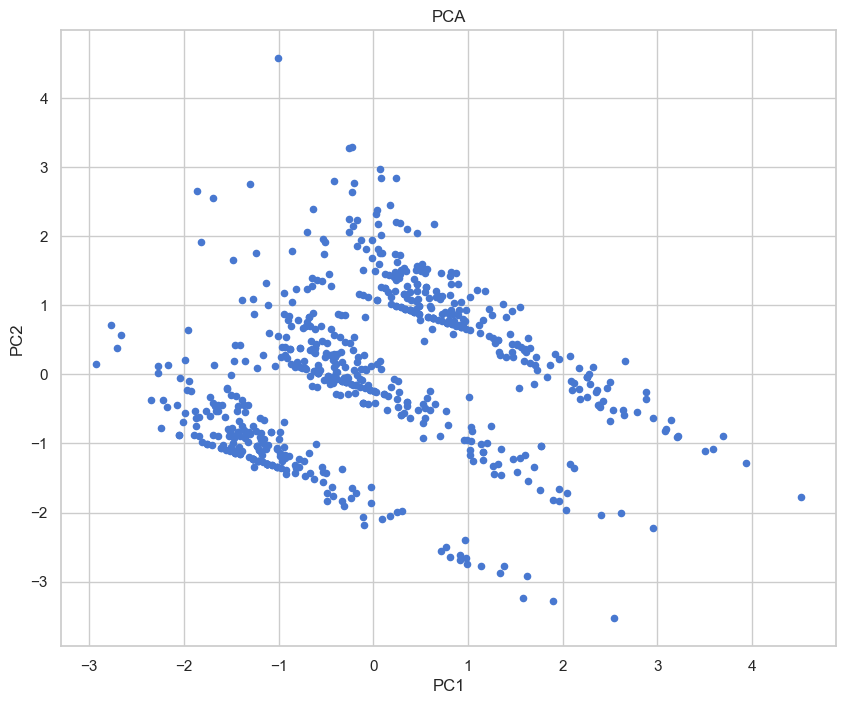

In [ ]:

#First two PCA components (PC1 and PC2)

hab_extended.plot.scatter(0, 1, figsize=(10, 8), title="PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [ ]:
# K-means clustering (3 clusters: Work oriented, balanced and leisure oriented)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10).fit(df_standardised)
predictions = kmeans.predict(df_standardised)
hab_extended["cluster"] = pd.Categorical(predictions)

c:\Users\nitac\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


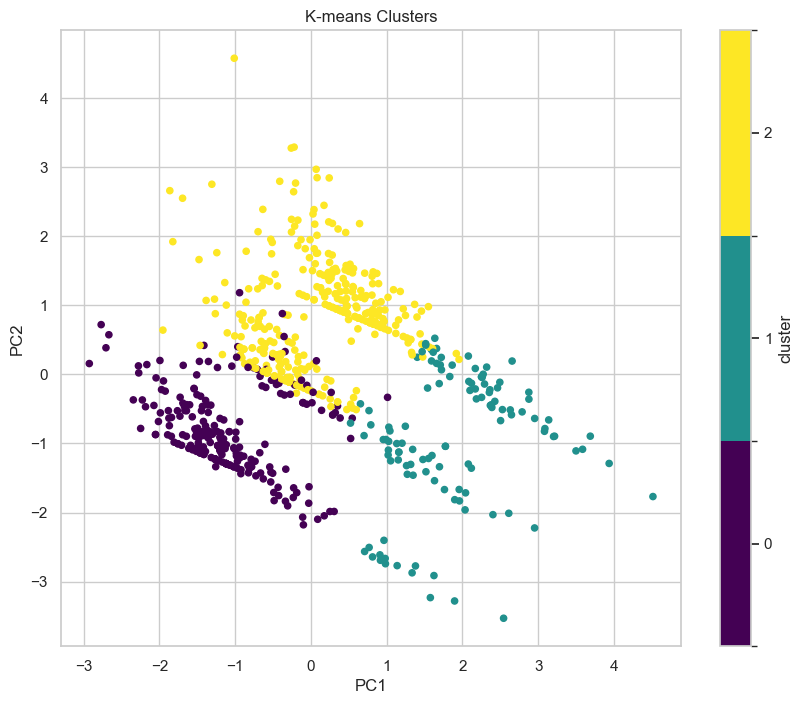

In [ ]:
# Clusters in PCA space

hab_extended.plot.scatter(0, 1, c="cluster", colormap="viridis", figsize=(10, 8),
title="K-means Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [ ]:
# Average activity patterns per cluster

cluster_profiles = hab_extended.groupby("cluster", observed=True)[quantitative].mean().round(1)
print("Average activity pattern per cluster:\n")
display(cluster_profiles)

Average activity pattern per cluster:



,A1,A2,A3,A4_bin,A5_bin
cluster,,,,,
0,23.9,555.8,54.6,0.2,0.0
1,368.4,431.9,19.7,0.6,0.7
2,10.3,544.6,73.3,0.6,1.0


In [ ]:
# check how many housholds are in the data
if "kohde" in hab.columns:
    hab_household = hab.groupby("kohde")[quantitative].mean().reset_index()
    print(f"Aggregated data to household level: {len(hab_household)} households")
 
    X = hab_household[quantitative]
else:
    print("No 'HOUSEHOLD' column found — analysis continues at individual level.")

Aggregated data to household level: 494 households


In [11]:
# avarage time use (hours per day)
avg_time = hab_household[["A1", "A2", "A3"]].mean()

print("\nEstimated average daily time (in hours) Finnish households spend on each activity:")
for activity, hours in avg_time.items():
    print(f"  {activity}: {hours:.2f} min per day")



Estimated average daily time (in hours) Finnish households spend on each activity:
  A1: 79.00 min per day
  A2: 528.82 min per day
  A3: 56.64 min per day


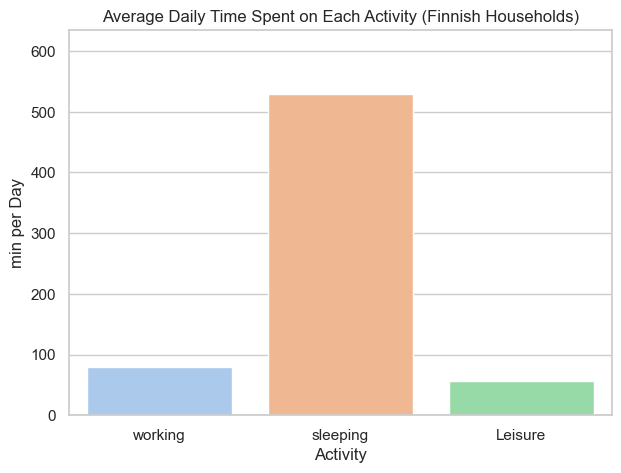

In [ ]:
#plot figure
activity_labels = {
    "A1": "working",
    "A2": "sleeping",
    "A3": "Leisure"
}

avg_time_named = avg_time.rename(index=activity_labels)


plt.figure(figsize=(7,5))
sns.barplot(x=avg_time_named.index, y=avg_time_named.values, hue= avg_time_named.index, palette="pastel")
plt.title("Average Daily Time Spent on Each Activity (Finnish Households)")
plt.ylabel("min per Day")
plt.xlabel("Activity")
plt.ylim(0, avg_time.max() * 1.2)
plt.show()

In [ ]:
import pandas as pd
from scipy import stats

# change aktivities to numeric
activity_cols = ["A1", "A2", "A3"]
hab[activity_cols] = hab[activity_cols].apply(pd.to_numeric, errors="coerce")

# avereges by living enviroment
print("\navarages by living enviroment:")
print(hab.groupby("ASALUE")[activity_cols].mean())

# avereges by week days
print("\navarages by week days:")
print(hab.groupby("pvknro")[activity_cols].mean())

#ANNOVA differences between living inviroments
print("\nStastical differences (ANOVA, enviroments):")
for a in activity_cols:
    groups = [g[a].dropna() for _, g in hab.groupby("ASALUE")]
    F, p = stats.f_oneway(*groups)
    print(f"{a}: F={F:.2f}, p={p:.4f}")



avarages by living enviroment:
               A1          A2         A3
ASALUE                                  
1.0     79.859611  521.032258  60.776344
2.0     73.521739  533.125000  47.634783
3.0     63.169643  559.380531  56.008850

avarages by week days:
               A1          A2         A3
pvknro                                  
1       94.846797  532.011173  48.342541
2       55.755287  526.325301  68.181269

Stastical differences (ANOVA, enviroments):
A1: F=0.53, p=0.5870
A2: F=6.44, p=0.0017
A3: F=1.45, p=0.2353


C:\Users\nitac\AppData\Local\Temp\ipykernel_30852\1372224880.py:17: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(


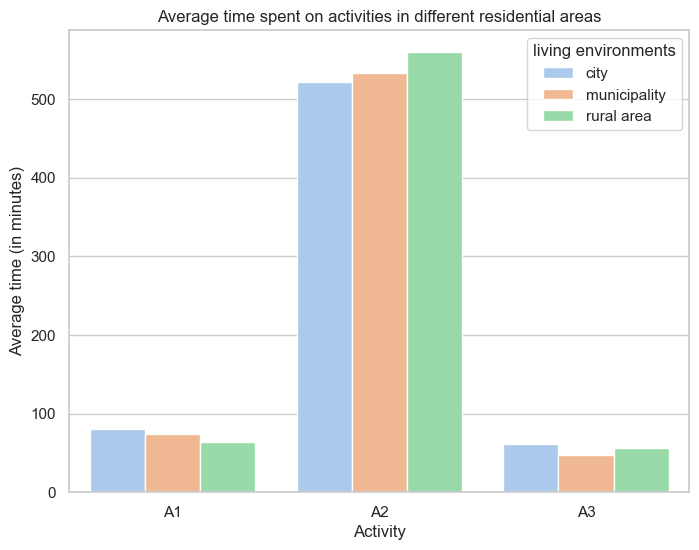

In [ ]:
#
palette = sns.color_palette("pastel")

means = hab.groupby("ASALUE")[activity_cols].mean().reset_index()

# change 1,0 2,0 ja 3,0 to living enviroment names
means["ASALUE"] = means["ASALUE"].replace({
    1.0: "city",
    2.0: "municipality",
    3.0: "rural area"
})

means_melted = means.melt(id_vars="ASALUE", var_name="Activity", value_name="Avarage time (min)")


plt.figure(figsize=(8,6))
sns.barplot(
    data=means_melted,
    x="Activity",
    y="Avarage time (min)",
    hue="ASALUE",
    palette=palette
)
plt.title("Average time spent on activities in different residential areas")
plt.xlabel("Activity")
plt.ylabel("Average time (in minutes)")
plt.legend(title="living environments")
plt.show()

In [ ]:
# change a4 and a5 to binary and take avarages and change to percentages
hab["A4_bin"] = hab["A4"].apply(lambda x: 1 if x == 1 else 0)
hab["A5_bin"] = hab["A5"].apply(lambda x: 1 if x == 1 else 0)

a4_a5 = hab.groupby("ASALUE")[["A4_bin", "A5_bin"]].mean().reset_index()
a4_a5[["A4_bin", "A5_bin"]] = a4_a5[["A4_bin", "A5_bin"]] * 100  
print(a4_a5)


   ASALUE     A4_bin     A5_bin
0     1.0  51.830443  63.776493
1     2.0  40.322581  67.741935
2     3.0  33.576642  55.474453


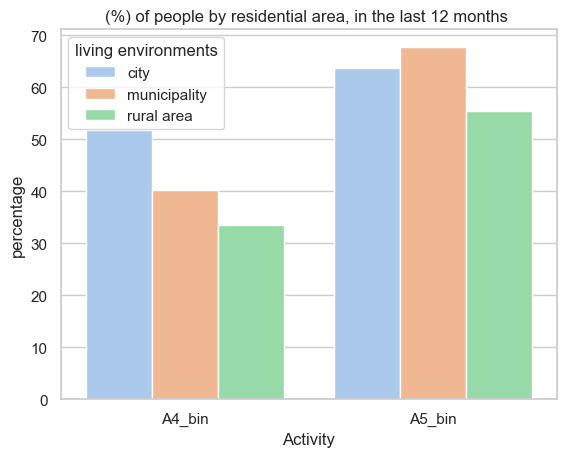

In [ ]:
# change 1,0 2,0 and 3,0 to enviroments names
a4_a5["ASALUE"] = means["ASALUE"].replace({
    1.0: "city",
    2.0: "municipality",
    3.0: "rural area"
})
sns.barplot(
    data=a4_a5.melt(id_vars="ASALUE", var_name="Activity", value_name="percentage"),
    x="Activity", y="percentage", hue="ASALUE", palette="pastel",
)
plt.title("(%) of people by residential area, in the last 12 months ")
plt.legend(title="living environments")
plt.show()
